# Perturbed Coin Model Analysis
This notebook validates the symmetry-analysis infrastructure used in the perturbed coin model workflow.  
It checks that the central classes and methods for tensor-product symmetry generators are available, including both the standard and SO(N)-specific implementations.  
It also verifies method signatures and wrapper consistency in `MatrixProductState`, ensuring coefficient extraction via `find_generators_coefficients` is correctly exposed for downstream analysis.

In [477]:
import inspect
from emachine_v2 import MatrixProductState
import Centraliser as cen
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D



plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = [10, 6]

print("=" * 70)
print("MODULE VALIDATION CHECK")
print("=" * 70)

# Check 1: TensorProductGroup exists and has key methods
print("\n[1] Checking Centraliser.TensorProductGroup...")
assert hasattr(cen, 'TensorProductGroup'), "TensorProductGroup class not found!"
tpg_methods = dir(cen.TensorProductGroup)
required_tpg_methods = ['find_symmetric_generators', 'find_generators_coefficients']
for method in required_tpg_methods:
    assert method in tpg_methods, f"TensorProductGroup missing method: {method}"
print("    ✓ TensorProductGroup class exists with required methods")

# Check 2: TensorProductGroupSO exists (new SO(N) framework)
print("\n[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...")
assert hasattr(cen, 'TensorProductGroupSO'), "TensorProductGroupSO class not found!"
tpgo_methods = dir(cen.TensorProductGroupSO)
for method in required_tpg_methods:
    assert method in tpgo_methods, f"TensorProductGroupSO missing method: {method}"
print("    ✓ TensorProductGroupSO class exists with required methods")

# Check 3: SON class exists for SO(N) basis generation
print("\n[3] Checking Centraliser.SON (SO(N) basis)...")
assert hasattr(cen, 'SON'), "SON class not found!"
assert hasattr(cen.SON, 'so_basis'), "SON missing so_basis method!"
print("    ✓ SON class exists with so_basis method")

# Check 4: find_generators_coefficients signature includes new parameters
print("\n[4] Checking find_generators_coefficients parameters...")
sig = inspect.signature(cen.TensorProductGroup.find_generators_coefficients)
params = list(sig.parameters.keys())
required_params = ['self', 'M', 'basis_generators', 'verbose', 'reference_coeffs']
for param in required_params:
    assert param in params, f"find_generators_coefficients missing parameter: {param}"
print(f"    ✓ Parameters: {params}")

# Check 5: MatrixProductState wrapper method exists
print("\n[5] Checking MatrixProductState.find_generators_coefficients wrapper...")
mps_methods = dir(MatrixProductState)
assert 'find_generators_coefficients' in mps_methods, "MatrixProductState missing wrapper method!"
mps_sig = inspect.signature(MatrixProductState.find_generators_coefficients)
print(f"    ✓ Wrapper method exists with parameters: {list(mps_sig.parameters.keys())}")

MODULE VALIDATION CHECK

[1] Checking Centraliser.TensorProductGroup...
    ✓ TensorProductGroup class exists with required methods

[2] Checking Centraliser.TensorProductGroupSO (SO(N) framework)...
    ✓ TensorProductGroupSO class exists with required methods

[3] Checking Centraliser.SON (SO(N) basis)...
    ✓ SON class exists with so_basis method

[4] Checking find_generators_coefficients parameters...
    ✓ Parameters: ['self', 'M', 'verbose', 'basis_generators', 'reference_coeffs']

[5] Checking MatrixProductState.find_generators_coefficients wrapper...
    ✓ Wrapper method exists with parameters: ['self', 'M', 'basis', 'verbose', 'dim', 'reference_coeffs']


In [478]:
import importlib
import emachine_v2 as EM
from emachine_v2 import pprint, purify

importlib.reload(EM)
importlib.reload(cen)

pc = EM.perturbed_coin

## Form of the model
The site matrices are given by the form:

In [479]:
pprint(pc(0.6, 0.8).A)

[[[0.6325 0.    ]
  [0.8944 0.    ]]

 [[0.     0.7746]
  [0.     0.4472]]]


## Check Correlation Length
The system becomes memoryless when it approaches the line $p = q$, we can observe this with the plots below.

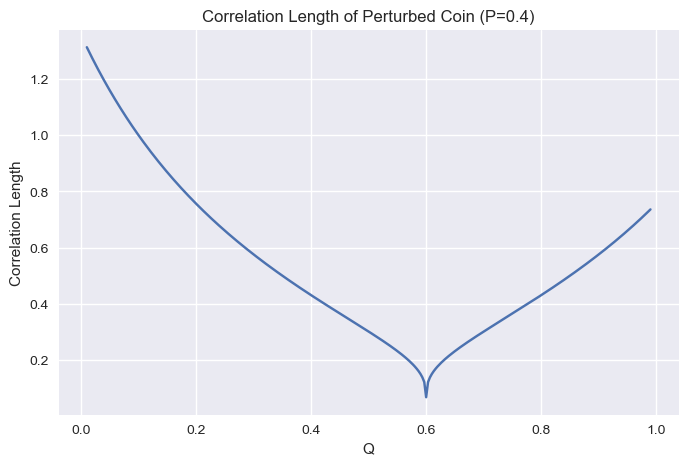

In [480]:
P = 0.4
Q = np.linspace(0.01,0.99, 300)

plt.figure(figsize=(8,5))
em = [pc(P,q) for q in Q]
corr = np.array([m.correlation_length() for m in em])

plt.plot(Q, corr)
plt.title(f"Correlation Length of Perturbed Coin (P={P})")
plt.xlabel("Q")
plt.ylabel("Correlation Length")
plt.show()


As we can see, the correlation length drops to 0 when $p =1- q$.

/Users/ernestchan/Desktop/EMachine/emachine_v2.py:1227: RuntimeWarning: divide by zero encountered in log2
  2-D array representing the classical transition matrix raised to power n.


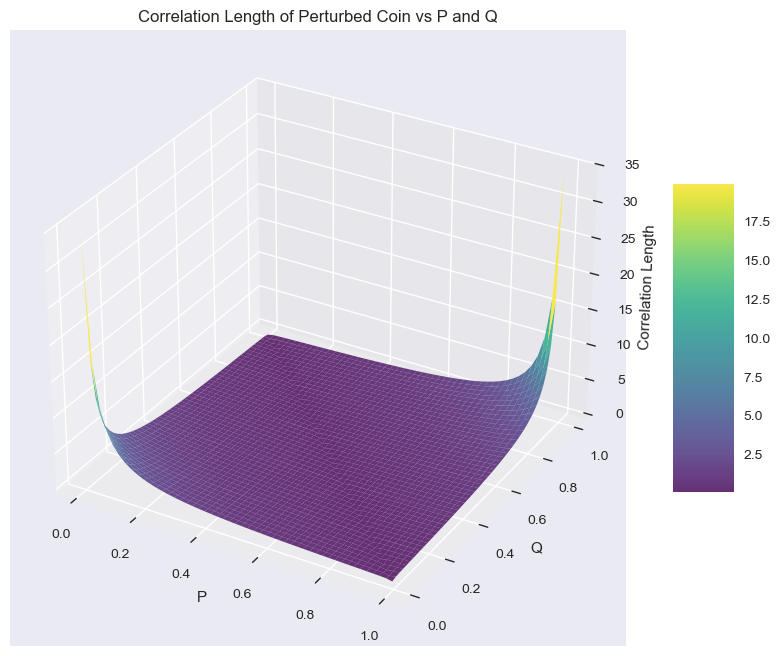

In [481]:
P_vals = np.linspace(0.01, 0.99, 50)
Q_vals = np.linspace(0.01, 0.99, 50)

# Create meshgrid for 3D plot
P_grid, Q_grid = np.meshgrid(P_vals, Q_vals)

# Compute correlation length for each (P, Q) pair
corr_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        corr_grid[j, i] = pc(P_vals[i], Q_vals[j]).correlation_length()

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, Q_grid, corr_grid, cmap='viridis', alpha=0.8)

ax.set_xlabel('P')
ax.set_ylabel('Q')
ax.set_zlabel('Correlation Length')
ax.set_title('Correlation Length of Perturbed Coin vs P and Q')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()


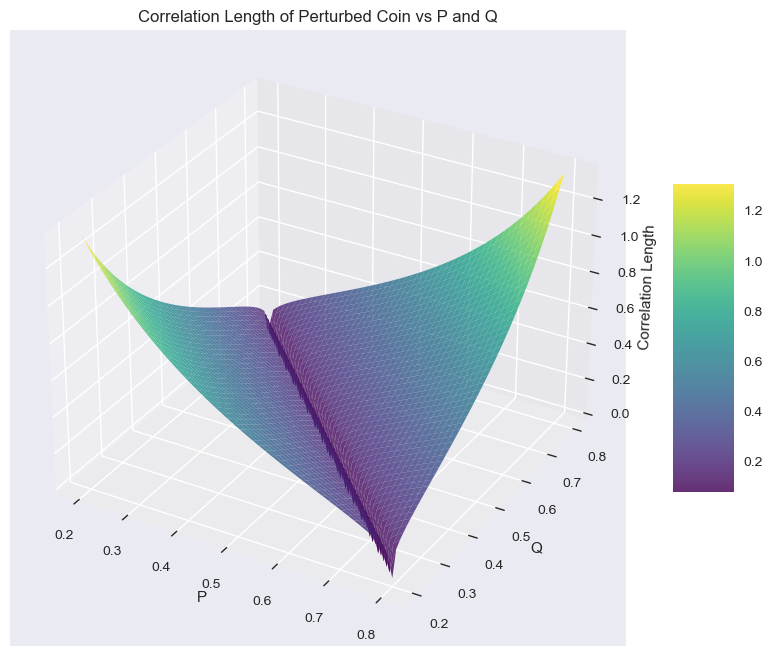

In [482]:
P_vals = np.linspace(0.2, 0.8, 50)
Q_vals = np.linspace(0.2, 0.8, 50)

# Create meshgrid for 3D plot
P_grid, Q_grid = np.meshgrid(P_vals, Q_vals)

# Compute correlation length for each (P, Q) pair
corr_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        corr_grid[j, i] = pc(P_vals[i], Q_vals[j]).correlation_length()

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, Q_grid, corr_grid, cmap='viridis', alpha=0.8)

ax.set_xlabel('P')
ax.set_ylabel('Q')
ax.set_zlabel('Correlation Length')
ax.set_title('Correlation Length of Perturbed Coin vs P and Q')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()


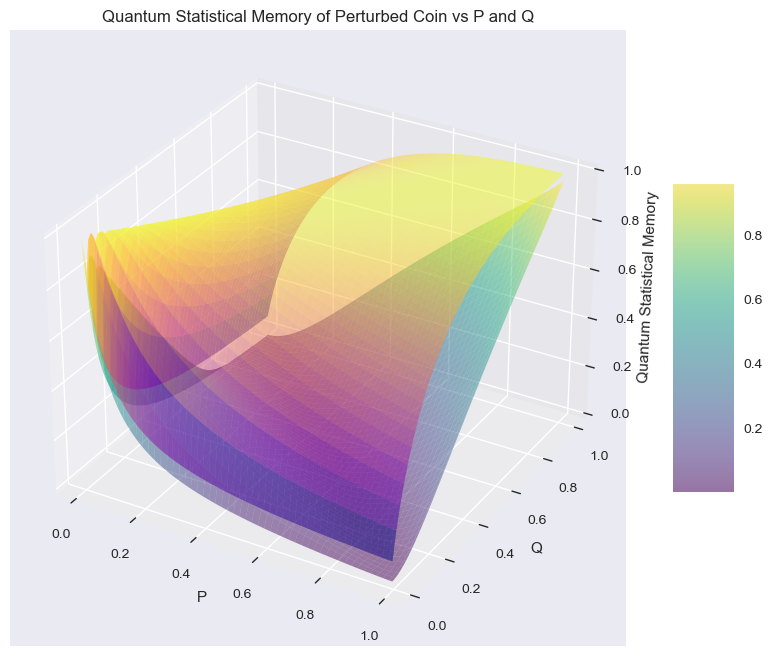

In [483]:
P_vals = np.linspace(0.01, 0.99, 100)
Q_vals = np.linspace(0.01, 0.99, 100)

# Create meshgrid for 3D plot
P_grid, Q_grid = np.meshgrid(P_vals, Q_vals)

# Compute quantum statistical memory for each (P, Q) pair
qsm_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        qsm_grid[j, i] = pc(P_vals[i], Q_vals[j]).quantum_statistical_memory()

sm_grid = np.zeros_like(P_grid)
for i in range(len(P_vals)):
    for j in range(len(Q_vals)):
        sm_grid[j, i] = pc(P_vals[i], Q_vals[j]).statistical_memory()

# Create 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(P_grid, Q_grid, qsm_grid, cmap='viridis', alpha=0.5)

surf2 = ax.plot_surface(P_grid, Q_grid, sm_grid, cmap='plasma', alpha=0.5)

ax.set_xlabel('P')
ax.set_ylabel('Q')
ax.set_zlabel('Quantum Statistical Memory')
ax.set_title('Quantum Statistical Memory of Perturbed Coin vs P and Q')

# Add colorbar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.show()

## Checking the Produced Sequence by the Model

In [484]:
print(em[181].propagator(40, np.array([1,0])))

[1 1 1 0 0 1 1 0 0 0 0 1 1 0 1 0 1 1 1 0 0 0 0 1 0 1 1 1 1 1 0 0 0 1 0 0 0
 1 0 0]


## Symmetry Finding for the Perturbed Coin

We now attempt to find the symmetry group generators for the perturbed coin process for a fixed value of $p \neq 1-q$.

In [485]:
Q = 0.6
ph_3_3 = pc(P, Q).parent_hamiltonian(3, 3)

print("The parent hamiltonian in consideration is:")
pprint(ph_3_3)
gen = [*pc(P, Q).sun_symmetry(ph_3_3, return_coeff = False)]

The parent hamiltonian in consideration is:
[[ 0.0009  0.0058 -0.0029 -0.003  -0.0168 -0.003   0.0228 -0.0014]
 [ 0.0058  0.4543 -0.2884 -0.1988  0.1561 -0.1988  0.1533 -0.1943]
 [-0.0029 -0.2884  0.1877  0.1477 -0.1221  0.1477 -0.0761  0.0709]
 [-0.003  -0.1988  0.1477  0.7113 -0.0799 -0.2887 -0.0785 -0.2193]
 [-0.0168  0.1561 -0.1221 -0.0799  0.5042 -0.0799 -0.4429 -0.0384]
 [-0.003  -0.1988  0.1477 -0.2887 -0.0799  0.7113 -0.0785 -0.2193]
 [ 0.0228  0.1533 -0.0761 -0.0785 -0.4429 -0.0785  0.6015 -0.0377]
 [-0.0014 -0.1943  0.0709 -0.2193 -0.0384 -0.2193 -0.0377  0.8288]]

SYMMETRIC GENERATORS ANALYSIS

⚠️  No symmetry found: The null space is empty.



Now for the case $p = q = 0.5$,

In [486]:
P = 0.499999
Q = 0.5
ph_3_3 = pc(P, Q).parent_hamiltonian(3, 3)

print("The parent hamiltonian in consideration is:")
pprint(ph_3_3)
print("Verifying that the MPS is in the ground space of the parent hamiltonian:")
print("ph_3_3 @ state = ", purify(ph_3_3 @ pc(P, Q).to_ground_space(3,np.array([[1,2],[3,4]]))))
gen = [*pc(P, Q).sun_symmetry(purify(ph_3_3), return_coeff = False)]


The parent hamiltonian in consideration is:
[[ 0.5  0.  -0.5  0.   0.   0.   0.   0. ]
 [ 0.   0.5  0.  -0.5  0.   0.   0.   0. ]
 [-0.5  0.   0.5  0.   0.   0.   0.   0. ]
 [ 0.  -0.5  0.   0.5  0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0.5  0.  -0.5  0. ]
 [ 0.   0.   0.   0.   0.   0.5  0.  -0.5]
 [ 0.   0.   0.   0.  -0.5  0.   0.5  0. ]
 [ 0.   0.   0.   0.   0.  -0.5  0.   0.5]]
Verifying that the MPS is in the ground space of the parent hamiltonian:
ph_3_3 @ state =  [0. 0. 0. 0. 0. 0. 0. 0.]

SYMMETRIC GENERATORS ANALYSIS

Found 1 generator(s) in the null space:
--------------------------------------------------------------------------------

Generator 1:
  Null space basis vector index: 0
  Coefficients in local su(2) basis (orthonormalized): [1. 0. 0.]

  Basis generators in su(2) (with non-zero coefficients):
    [0] (coeff: 1.0):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

  Local su(2) generator (Hermitian enforced):
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

---------------------------

We see that the hamiltonian is of the form $H = I \otimes (I-\sigma_x)\otimes I$.

In [487]:
sig_x = np.array([[0, 1], [1, 0]])
recon_ham = np.kron(np.eye(2), np.kron((np.eye(2)-sig_x), np.eye(2)))
print("Checking the form of the Hamiltonian:")
print(0.5*recon_ham)

Checking the form of the Hamiltonian:
[[ 0.5  0.  -0.5 -0.   0.   0.  -0.  -0. ]
 [ 0.   0.5 -0.  -0.5  0.   0.  -0.  -0. ]
 [-0.5 -0.   0.5  0.  -0.  -0.   0.   0. ]
 [-0.  -0.5  0.   0.5 -0.  -0.   0.   0. ]
 [ 0.   0.  -0.  -0.   0.5  0.  -0.5 -0. ]
 [ 0.   0.  -0.  -0.   0.   0.5 -0.  -0.5]
 [-0.  -0.   0.   0.  -0.5 -0.   0.5  0. ]
 [-0.  -0.   0.   0.  -0.  -0.5  0.   0.5]]


## Finding Virtual Symmetry

Next we find the associated virtual symmetry of the system

In [488]:
vgen = pc(P, Q).virtual_symmetry(purify(ph_3_3), verbose=True)


Physical generator G:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

Virtual generator found:
  Phase: 1.000000+0.000000j
  Error: 2.160247e-06
  Relative error: 1.527525e-06
  Generator K:
[[ 1.+0.j -0.+0.j]
 [-0.+0.j -1.+0.j]]


In [489]:
em_can = pc(P, Q).can_l()
print("The canonical form of the MPS is:")
pprint(em_can.A)
print("Verifying that the MPS is in the ground space of the parent hamiltonian:")
pprint(ph_3_3 @ em_can.to_ground_space(3, np.array([[1,2],[3,4]])))
print("Transfer Matrix:")
pprint(em_can.E)

The canonical form of the MPS is:
[[[ 0.7071  0.7071]
  [ 0.      0.    ]]

 [[ 0.7071 -0.7071]
  [-0.      0.    ]]]
Verifying that the MPS is in the ground space of the parent hamiltonian:
[0. 0. 0. 0. 0. 0. 0. 0.]
Transfer Matrix:
[[1. 0. 0. 1.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


### Verifying the Generator Equation

In [490]:
A = np.array(em_can.A)
sig_z = np.array([[1, 0], [0, -1]])

Hence, we can conclude that rotations generated by $\sigma_x$ on the physical level can be projected onto the virtual level as rotations generated by $\sigma_z$. As they are both 1-D subspaces of SU(2), the 2-cocycle is trivially constant.

In [491]:
from scipy.linalg import expm
def _fmt(M, precision=4):
    return np.array2string(
        np.asarray(M),
        precision=precision,
        suppress_small=True,
        max_line_width=120
    )

def _print_two_columns(
    left,
    right,
    left_title="Physical",
    right_title="Virtual",
    sep="   |   ",
    left_width=35,
    right_width=35,
    ):
    L = [line.strip() for line in left.splitlines()]
    R = [line.strip() for line in right.splitlines()]
    n = max(len(L), len(R))
    L += [""] * (n - len(L))
    R += [""] * (n - len(R))
    print(f"\n{left_title:<{left_width}}{sep}{right_title:<{right_width}}")
    print(f"{'-'*left_width}{sep}{'-'*right_width}")
    for l, r in zip(L, R):
        print(f"{l:<{left_width}}{sep}{r:<{right_width}}")

def compare_physical_virtual_generators(mps, T_generators, K_generators, angles=None):
    """
    Compare the effect of physical vs virtual generator exponentials on the MPS.
    
    Parameters
    ----------
    mps : MatrixProductState
        The MPS instance
    T_generators : list
        Physical space generators [T1, T2, T3]
    K_generators : list
        Virtual space generators [K1, K2, K3]
    angles : list, optional
        List of angles to sample. If None, uses [0, π/4, π/2, 3π/4, π]
    """
    if angles is None:
        angles = [0, np.pi/4, np.pi/3, np.pi/2, 3*np.pi/4, np.pi]
    
    results = {}
    
    for gen_idx, (T, K) in enumerate(zip(T_generators, K_generators)):
        print(f"\n{'='*70}")
        print(f"Generator {gen_idx + 1}")
        print(f"{'='*70}")
        
        gen_results = {'angles': angles, 'data': []}
        
        for theta in angles:
            print("\nFor angle θ =", round(theta/np.pi, 4), "π")
            # Apply to physical index
            mps_phys = mps.apply_generator(T, theta=theta)
            
            # Exponentiate virtual generator: V_virt = exp(i*theta*K)
            V_virt = expm(1j * theta * K)
            # Apply virtual transformation to bond indices
            mps_virt_A = np.array([V_virt @ np.array(a) @ V_virt.conj().T for a in mps.A])
            mps_virt = type(mps)(mps_virt_A)
            # Compare the A tensors directly
            for s, (A_phys, A_virt) in enumerate(zip(mps_phys.A, mps_virt.A)):
                print(f"\nSite matrix A[{s}]")
                _print_two_columns(_fmt(A_phys), _fmt(A_virt), "Physical", "Virtual")
            print("\nRelative Phases:", (np.angle(mps_phys.A[0,0,0]/mps_virt.A[0,0,0])/np.pi).round(4), "π")
            print((np.angle(mps_phys.A[0,0,1]/mps_virt.A[0,0,1])/np.pi).round(4), "π")
            print((np.angle(mps_phys.A[1,0,0]/mps_virt.A[1,0,0])/np.pi).round(4), "π")
            print((np.angle(mps_phys.A[1,0,1]/mps_virt.A[1,0,1])/np.pi).round(4), "π")
            print(f"\n{'='*70}")
            
            gen_results["data"].append({
                "theta": theta,
                "A_phys": np.array(mps_phys.A, dtype=complex),
                "A_virt": np.array(mps_virt.A, dtype=complex),
            })

        results[f"generator_{gen_idx}"] = gen_results

    return results
# Using T1, T2, T3 and K1, K2, K3 from your notebook
results = compare_physical_virtual_generators(pc(P, Q).can_l(), gen, [vgen[0]["generator"]])



Generator 1

For angle θ = 0.0 π

Site matrix A[0]

Physical                              |   Virtual                            
-----------------------------------   |   -----------------------------------
[[0.7071+0.j 0.7071+0.j]              |   [[0.7071+0.j 0.7071+0.j]           
[0.    +0.j 0.    +0.j]]              |   [0.    +0.j 0.    +0.j]]           

Site matrix A[1]

Physical                              |   Virtual                            
-----------------------------------   |   -----------------------------------
[[ 0.7071+0.j -0.7071+0.j]            |   [[ 0.7071+0.j -0.7071+0.j]         
[-0.    +0.j  0.    +0.j]]            |   [-0.    +0.j  0.    +0.j]]         

Relative Phases: 0.0 π
0.0 π
0.0 π
-0.0 π


For angle θ = 0.25 π

Site matrix A[0]

Physical                              |   Virtual                            
-----------------------------------   |   -----------------------------------
[[0.5+0.5j 0.5-0.5j]                  |   [[ 0.7071+0.j     -0.

## Discrete Symmetry of Parent Hamiltonian via Permutation Group

We investigate the permutation symmetry of symbols in a stochastic system by its Hamiltonian.

In [492]:
pc(P, Q).find_discrete_symmetry(ph_3_3, verbose=True)

Permutation index 0 commutes with M.
Permutation index 1 commutes with M.
Total symmetries found: 2
Symmetry indices: [0, 1]


[array([[1.+0.j, 0.+0.j],
        [0.+0.j, 1.+0.j]]),
 array([[0.+0.j, 1.+0.j],
        [1.+0.j, 0.+0.j]])]

## Projectiion of Discrete Symmetry onto Virtual Level
The projection acts via the same equation, $U^{xy}A^y_{ij}=e^{i\phi}V_{ik}A^x_{kl}V_{lj}^{-1}$, but this time we don't have to Taylor expand the equation to get the equation for the generators.
To solve this, we can do, $U^{xy}A^{y}_{ij}V_{jk} - e^{i\phi}V_{ij}A^{x}_{jk} = 0 \Rightarrow B^{x}_{ij}V_{jk} - e^{i\phi}V_{ij}A^{x}_{jk} = 0 $

In [493]:
pc_gauge = pc(P, Q)^np.array([[0, 2], [2, 0]])
print(pc_gauge.A)
pprint(ph_3_3 @ pc_gauge.to_ground_space(3, np.array([[1,2],[3,4]])))


[[[0.         0.70710678]
  [0.         0.70710749]]

 [[0.70710678 0.        ]
  [0.70710607 0.        ]]]
[0. 0. 0. 0. 0. 0. 0. 0.]


We can conclude that in general, if $p = q$, for the dihedral symmetry group $D_2 = \{e, d\}$ on the physical level, the element $e$ corresponds to the set of gauge matrices, 
$$\begin{equation}
e \rightarrow
\begin{pmatrix}
a & 0\\
0 & a\\
\end{pmatrix}
\end{equation}
$$
, where a is a free elements. For the element $d$ correesponds to matrices,
$$\begin{equation}
d \rightarrow
\begin{pmatrix} 
0 & b\\
b & 0\\
\end{pmatrix}
\end{equation}
$$
, where b is a free element. 

In [ ]:
result = pc(0.5, 0.5).virtual_discrete_symmetry(ph_3_3, verbose=True)

[{'permutation': array([[1.+0.j, 0.+0.j],
         [0.+0.j, 1.+0.j]]),
  'phi': np.float64(0.0),
  'null_vectors': [array([[-0.70710678+0.j,  0.        +0.j],
          [ 0.        +0.j, -0.70710678+0.j]])]},
 {'permutation': array([[1.+0.j, 0.+0.j],
         [0.+0.j, 1.+0.j]]),
  'phi': np.float64(6.283185307179586),
  'null_vectors': [array([[0.67259997+0.21821315j, 0.        +0.j        ],
          [0.        +0.j        , 0.67259997+0.21821315j]])]},
 {'permutation': array([[0.+0.j, 1.+0.j],
         [1.+0.j, 0.+0.j]]),
  'phi': np.float64(0.0),
  'null_vectors': [array([[0.        +0.j, 0.70710678+0.j],
          [0.70710678+0.j, 0.        +0.j]])]},
 {'permutation': array([[0.+0.j, 1.+0.j],
         [1.+0.j, 0.+0.j]]),
  'phi': np.float64(6.283185307179586),
  'null_vectors': [array([[ 0.        +0.j, -0.70710678+0.j],
          [-0.70710678+0.j,  0.        +0.j]])]}]